# Titanic — Exploratory Data Analysis

**Goal:** Understand the data before modelling — distributions, missing values, survival patterns, and feature relationships.

**Dataset:** Kaggle Titanic (891 training passengers, 418 test passengers)  
**Target:** `Survived` (0 = deceased, 1 = survived)  
**Metric:** Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train: {train.shape}  |  Test: {test.shape}")

Train: (891, 12)  |  Test: (418, 11)


---
## 1. Data Overview

In [2]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
train.Cabin.str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [4]:
train.Pclass.unique()

array([3, 1, 2], dtype=int64)

In [5]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
## 2. Missing Values

In [7]:
def missing_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({"Missing": missing, "% of rows": pct})
    summary = summary[summary["Missing"] > 0].sort_values("Missing", ascending=False)
    print(f"--- {label} ---")
    return summary

display(missing_summary(train, "Train"))
display(missing_summary(test,  "Test"))

--- Train ---


,Missing,% of rows
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


--- Test ---


,Missing,% of rows
Cabin,327,78.2
Age,86,20.6
Fare,1,0.2


**Observations:**
- `Cabin` is missing for ~77% of passengers — too sparse for direct use; converted to binary `HasCabin`.
- `Age` is missing for ~20% — needs imputation; dropping rows loses useful training signal.
- `Embarked` is missing for only 2 rows in train — safe to impute with mode.
- `Fare` is missing for 1 row in test — safe to impute with median.

---
## 3. Target Distribution

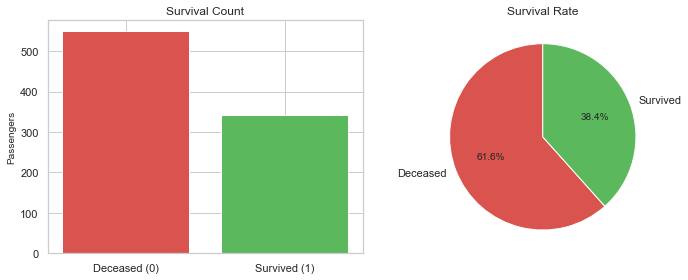

Overall survival rate: 38.4%


In [8]:
survival_counts = train["Survived"].value_counts()
survival_pct    = train["Survived"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Deceased (0)", "Survived (1)"], survival_counts.values, color=["#d9534f", "#5cb85c"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Passengers")

axes[1].pie(survival_pct.values, labels=["Deceased", "Survived"], autopct="%1.1f%%",
            colors=["#d9534f", "#5cb85c"], startangle=90)
axes[1].set_title("Survival Rate")

plt.tight_layout()
plt.show()

print(f"Overall survival rate: {survival_pct[1]:.1f}%")

**Observation:** The dataset is moderately imbalanced — 38.4% survived. Not severe enough to require resampling, but worth keeping in mind when interpreting accuracy alone.

---
## 4. Survival by Key Features

### 4.1 Sex

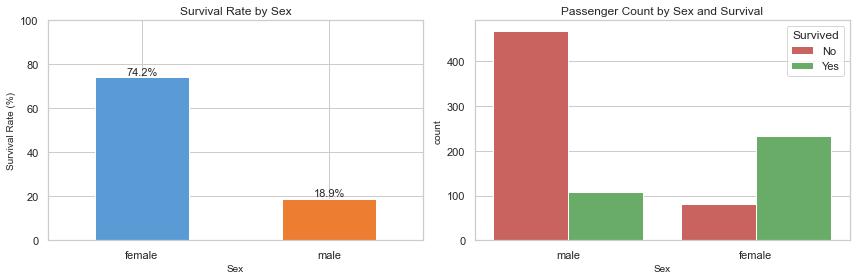

In [9]:
sex_survival = train.groupby("Sex")["Survived"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_survival.plot(kind="bar", ax=axes[0], color=["#5b9bd5", "#ed7d31"], rot=0)
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 100)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

sns.countplot(data=train, x="Sex", hue="Survived", ax=axes[1],
              palette={0: "#d9534f", 1: "#5cb85c"})
axes[1].set_title("Passenger Count by Sex and Survival")
axes[1].legend(title="Survived", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

**Observation:** Sex is the strongest single predictor — 74% of women survived vs 19% of men ("women and children first" policy).

### 4.2 Passenger Class (Pclass)

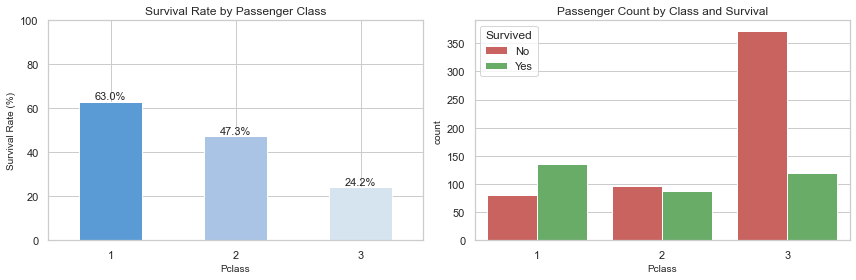

In [10]:
pclass_survival = train.groupby("Pclass")["Survived"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pclass_survival.plot(kind="bar", ax=axes[0], color=["#5b9bd5", "#a9c4e5", "#d6e4f0"], rot=0)
axes[0].set_title("Survival Rate by Passenger Class")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_xlabel("Pclass")
axes[0].set_ylim(0, 100)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

sns.countplot(data=train, x="Pclass", hue="Survived", ax=axes[1],
              palette={0: "#d9534f", 1: "#5cb85c"})
axes[1].set_title("Passenger Count by Class and Survival")
axes[1].legend(title="Survived", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

**Observation:** Clear socio-economic effect — 1st class survival rate (~63%) is roughly 3x that of 3rd class (~24%). Pclass is a strong feature.

### 4.3 Age

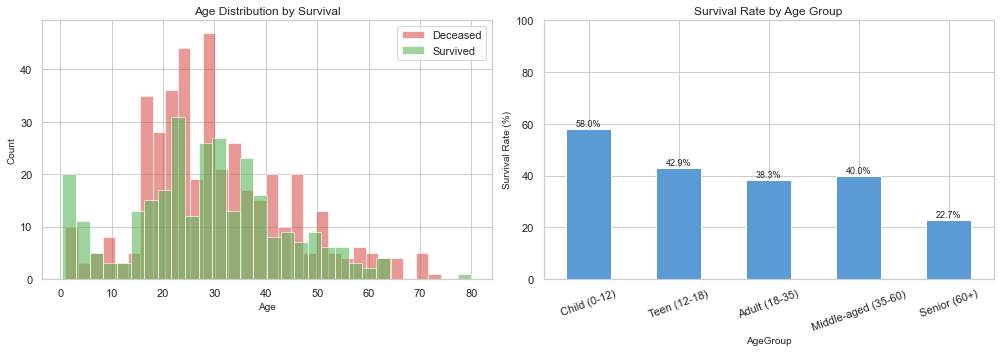

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for survived, label, color in [(0, "Deceased", "#d9534f"), (1, "Survived", "#5cb85c")]:
    subset = train[train["Survived"] == survived]["Age"].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

bins = [0, 12, 18, 35, 60, 100]
labels = ["Child (0-12)", "Teen (12-18)", "Adult (18-35)", "Middle-aged (35-60)", "Senior (60+)"]
train["AgeGroup"] = pd.cut(train["Age"], bins=bins, labels=labels)
age_survival = train.groupby("AgeGroup", observed=True)["Survived"].mean() * 100
age_survival.plot(kind="bar", ax=axes[1], color="#5b9bd5", rot=20)
axes[1].set_title("Survival Rate by Age Group")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 100)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=9)

train.drop(columns=["AgeGroup"], inplace=True)
plt.tight_layout()
plt.show()

**Observation:** Children (0–12) have a noticeably higher survival rate. Seniors (60+) fare worst. The effect is moderate — Age alone is not a strong predictor but contributes alongside Sex and Pclass.

### 4.4 Fare

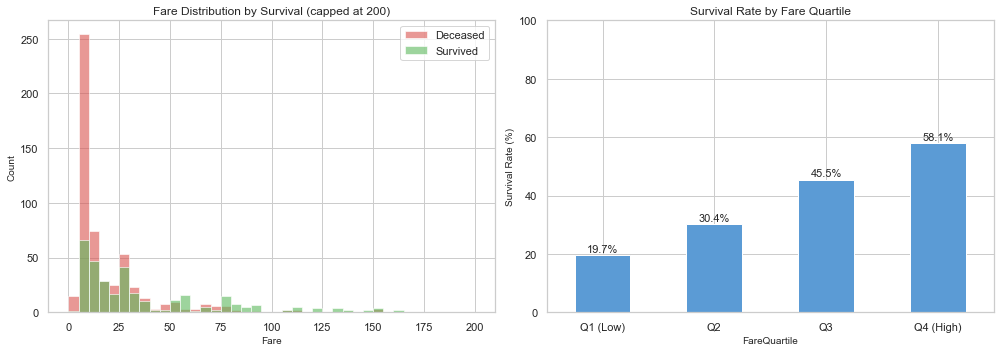

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for survived, label, color in [(0, "Deceased", "#d9534f"), (1, "Survived", "#5cb85c")]:
    subset = train[train["Survived"] == survived]["Fare"].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, label=label, color=color, range=(0, 200))
axes[0].set_title("Fare Distribution by Survival (capped at 200)")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")
axes[0].legend()

train["FareQuartile"] = pd.qcut(train["Fare"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
fare_survival = train.groupby("FareQuartile", observed=True)["Survived"].mean() * 100
fare_survival.plot(kind="bar", ax=axes[1], color="#5b9bd5", rot=0)
axes[1].set_title("Survival Rate by Fare Quartile")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 100)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

train.drop(columns=["FareQuartile"], inplace=True)
plt.tight_layout()
plt.show()

**Observation:** Strong positive correlation between fare and survival — highest quartile passengers survived at ~66% vs ~20% for lowest. Fare is correlated with Pclass so these two features carry overlapping information.

### 4.5 Embarked

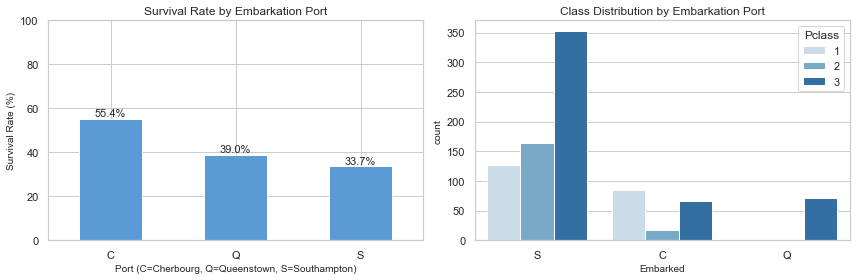

In [13]:
embarked_survival = train.groupby("Embarked")["Survived"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

embarked_survival.plot(kind="bar", ax=axes[0], color="#5b9bd5", rot=0)
axes[0].set_title("Survival Rate by Embarkation Port")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_xlabel("Port (C=Cherbourg, Q=Queenstown, S=Southampton)")
axes[0].set_ylim(0, 100)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

sns.countplot(data=train, x="Embarked", hue="Pclass", ax=axes[1],
              palette="Blues")
axes[1].set_title("Class Distribution by Embarkation Port")
axes[1].legend(title="Pclass")

plt.tight_layout()
plt.show()

**Observation:** Cherbourg (C) passengers survived at ~55% — significantly higher than Southampton (S) at ~34%. This is largely explained by class composition: Cherbourg had a higher proportion of 1st class passengers. Embarked is likely a proxy for Pclass rather than an independent predictor.

### 4.6 Cabin (HasCabin)

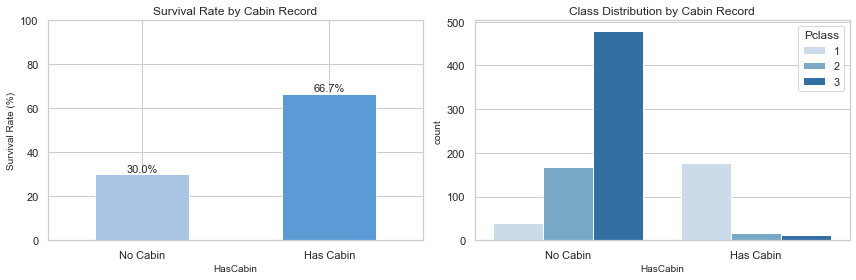

In [14]:
train["HasCabin"] = train["Cabin"].notna().astype(int)
cabin_survival = train.groupby("HasCabin")["Survived"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cabin_survival.plot(kind="bar", ax=axes[0], color=["#a9c4e5", "#5b9bd5"], rot=0)
axes[0].set_title("Survival Rate by Cabin Record")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_xticklabels(["No Cabin", "Has Cabin"])
axes[0].set_ylim(0, 100)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

sns.countplot(data=train, x="HasCabin", hue="Pclass", ax=axes[1], palette="Blues")
axes[1].set_title("Class Distribution by Cabin Record")
axes[1].set_xticklabels(["No Cabin", "Has Cabin"])
axes[1].legend(title="Pclass")

train.drop(columns=["HasCabin"], inplace=True)
plt.tight_layout()
plt.show()

**Observation:** Passengers with a recorded cabin number survived at ~67% vs ~30% without. Again, this heavily overlaps with Pclass — cabin records are concentrated in 1st class. Useful as a binary feature but partially redundant.

### 4.7 Family Size (SibSp + Parch)

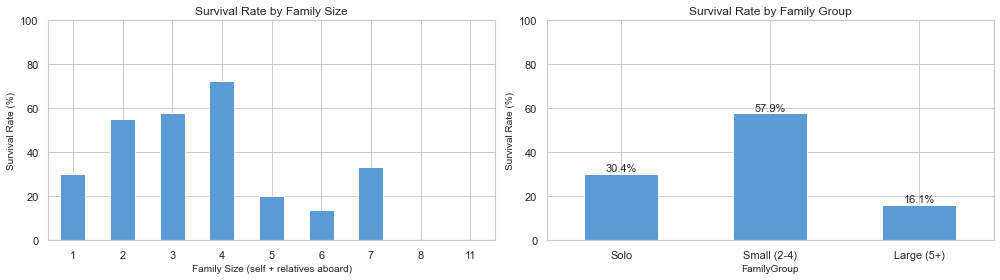

In [15]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1  # +1 for the passenger themselves
family_survival = train.groupby("FamilySize")["Survived"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

family_survival.plot(kind="bar", ax=axes[0], color="#5b9bd5", rot=0)
axes[0].set_title("Survival Rate by Family Size")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_xlabel("Family Size (self + relatives aboard)")
axes[0].set_ylim(0, 100)

train["FamilyGroup"] = train["FamilySize"].map(
    lambda x: "Solo" if x == 1 else ("Small (2-4)" if x <= 4 else "Large (5+)")
)
fg_survival = train.groupby("FamilyGroup")["Survived"].mean() * 100
fg_survival.reindex(["Solo", "Small (2-4)", "Large (5+)"]).plot(kind="bar", ax=axes[1], color="#5b9bd5", rot=0)
axes[1].set_title("Survival Rate by Family Group")
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_ylim(0, 100)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)

train.drop(columns=["FamilySize", "FamilyGroup"], inplace=True)
plt.tight_layout()
plt.show()

**Observation:** Solo travellers and very large families (5+) had the lowest survival rates. Small families (2–4) survived at the highest rate. A `FamilySize` or `IsAlone` feature could add signal beyond raw `SibSp`/`Parch`.

---
## 5. Correlation Analysis

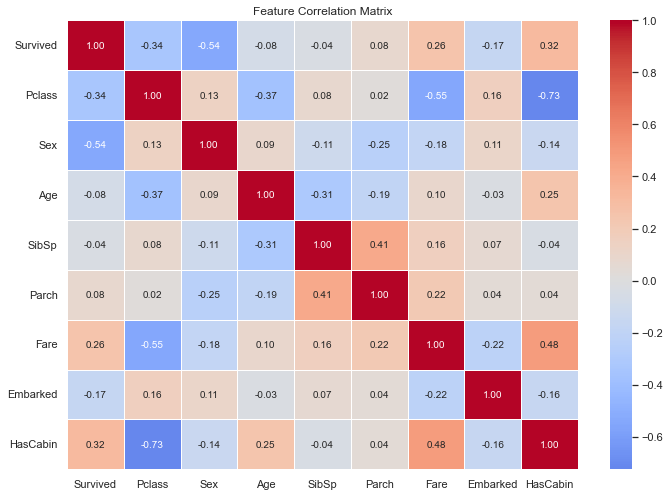

In [16]:
from sklearn.preprocessing import LabelEncoder

corr_df = train[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Cabin"]].copy()
corr_df["Sex"]      = LabelEncoder().fit_transform(corr_df["Sex"])
corr_df["Embarked"] = LabelEncoder().fit_transform(corr_df["Embarked"].fillna("S"))
corr_df["HasCabin"] = corr_df["Cabin"].notna().astype(int)
corr_df.drop(columns=["Cabin"], inplace=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, annot_kws={"size": 10}
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations:**
- `Sex` and `Pclass` are the strongest individual correlates with `Survived`.
- `Fare` and `Pclass` are strongly inversely correlated (-0.55) — they carry overlapping information.
- `HasCabin` correlates strongly with `Fare` and `Pclass` — partial redundancy confirmed.
- `SibSp` and `Parch` are weakly correlated with survival individually but may contribute as a combined `FamilySize` feature.

---
## 6. Sex × Pclass Interaction

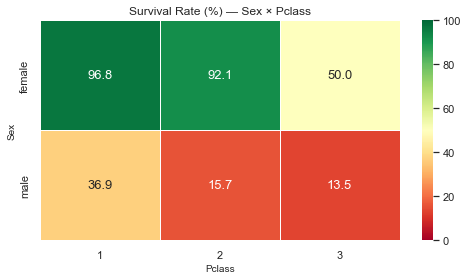

In [17]:
pivot = train.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean") * 100

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, annot_kws={"size": 13})
plt.title("Survival Rate (%) — Sex × Pclass")
plt.tight_layout()
plt.show()

**Observation:** The interaction between Sex and Pclass is striking. Even 3rd class women survived at ~50%, while 1st class men survived at only ~37%. Sex dominates within each class, but class still matters — especially for men.

---
## 7. Key Insights & Feature Engineering Candidates

| Feature | Signal | Notes |
|---|---|---|
| `Sex` | **Very strong** | Strongest single predictor |
| `Pclass` | **Strong** | Clear class gradient |
| `Fare` | **Moderate–Strong** | Correlated with Pclass; partial redundancy |
| `Age` | **Moderate** | Children advantage; needs imputation |
| `HasCabin` | **Moderate** | Proxy for wealth/class |
| `Embarked` | **Weak** | Largely explained by Pclass composition |
| `SibSp` / `Parch` | **Weak individually** | Better as combined `FamilySize` or `IsAlone` |

**Candidates to engineer and test:**
- `FamilySize` = `SibSp + Parch + 1`
- `IsAlone` = 1 if FamilySize == 1
- `Title` extracted from `Name` (Mr, Mrs, Miss, Master) — encodes Sex + Age group implicitly
- Drop or de-weight `Embarked` and `Fare` given correlation with `Pclass`

**Observations:**
- `Mrs` and `Miss` dominate survival (female titles) — consistent with the Sex finding.
- `Master` (young boys) survives at ~57% despite being male — the "children first" effect is real.
- `Mr` has the lowest survival rate (~16%) — adult males were deprioritised.
- Rare titles (Major, Col, Rev, Dr, Capt, etc.) have **n ≤ 7** each. Any survival rate for these titles — 0% or 100% — is statistically meaningless. A single passenger determines the entire rate.
- The right chart shows that rare titles cluster almost entirely in 1st/2nd class — so their survival signal (where it exists) is confounded with Pclass, not the title itself.
- **Conclusion:** Collapsing rare titles into a single `"Rare"` bucket is the right call. The frequency threshold should be set high enough to exclude Dr (n=7) and Rev (n=6) — threshold ≥ 10 is appropriate.

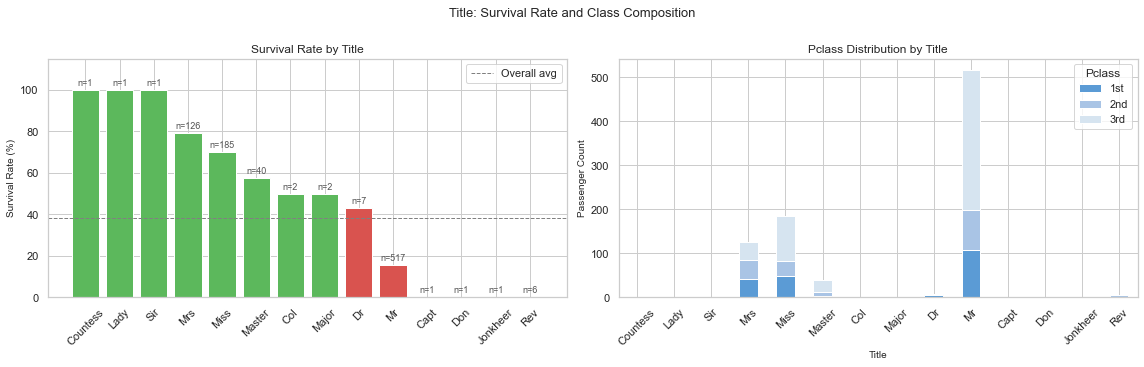


--- Title stats ---
   Title  Count  SurvivalRate
Countess      1    100.000000
    Lady      1    100.000000
     Sir      1    100.000000
     Mrs    126     79.365079
    Miss    185     70.270270
  Master     40     57.500000
     Col      2     50.000000
   Major      2     50.000000
      Dr      7     42.857143
      Mr    517     15.667311
    Capt      1      0.000000
     Don      1      0.000000
Jonkheer      1      0.000000
     Rev      6      0.000000


In [18]:
df = train.copy()
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

title_stats = (
    df.groupby("Title")
    .agg(Count=("Survived", "count"), SurvivalRate=("Survived", "mean"))
    .reset_index()
)
title_stats["SurvivalRate"] *= 100
title_stats = title_stats.sort_values("SurvivalRate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Survival rate per title, annotated with sample size ---
colors = ["#5cb85c" if r >= 50 else "#d9534f" for r in title_stats["SurvivalRate"]]
bars = axes[0].bar(title_stats["Title"], title_stats["SurvivalRate"], color=colors)
axes[0].set_title("Survival Rate by Title")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(y=train["Survived"].mean() * 100, color="gray", linestyle="--", linewidth=1, label="Overall avg")
axes[0].legend()
for bar, count in zip(bars, title_stats["Count"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
        f"n={count}", ha="center", fontsize=9, color="#555555"
    )

# --- Right: Pclass distribution per title (does the title correlate with class?) ---
pclass_by_title = (
    df.groupby(["Title", "Pclass"])
    .size()
    .unstack(fill_value=0)
    .reindex(title_stats["Title"])
)
pclass_by_title.plot(
    kind="bar", ax=axes[1], stacked=True,
    color=["#5b9bd5", "#a9c4e5", "#d6e4f0"], rot=45
)
axes[1].set_title("Pclass Distribution by Title")
axes[1].set_ylabel("Passenger Count")
axes[1].legend(title="Pclass", labels=["1st", "2nd", "3rd"])

plt.suptitle("Title: Survival Rate and Class Composition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n--- Title stats ---")
print(title_stats.to_string(index=False))

---
## 8. Title Analysis

Titles extracted from passenger names reveal socio-economic status and role on board. The question is whether rare titles (Major, Col, Dr, Rev, etc.) have meaningfully different survival rates — and whether those differences are real signal or just small-sample noise.